# Cross Validation Examples

---
This is adapted from the _Implement K-Fold Cross-Validation_ example on the [GitHub Pages from 9 Jan 2025](https://adsai.buas.nl/Study%20Content/Introduction%20to%20Machine%20Learning/[Wk6_IV]EvaluateCrossvalidation.html#2-implement-k-fold-cross-validation)

In [41]:
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
import numpy as np
import pandas as pd

## Set up the data

Replace the path with your copy of the data set available on the [GitHub Pages from 8 Jan 2025](https://adsai.buas.nl/Study%20Content/Math_ML/assets/house-prices.csv)

In [ ]:
# set to local copy
df = pd.read_csv('./datasets/house-prices.csv')

df['Brick_bin'] = df['Brick'].apply(lambda x: 1 if x== 'Yes' else 0)


df = pd.get_dummies(df, columns=['Neighborhood'], drop_first=True)

df.drop(columns=['Brick'], inplace=True)

X = df.drop(columns=['Price'])
y = df['Price']
# Convert to numpy arrays
X = df.drop(columns=['Price']).to_numpy()
y = df['Price'].to_numpy()

In [49]:
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression

# initializing K-Fold for cross validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)


# storing the scores
scores = []

# performing K-Fold cross validation
for train_idx, val_idx in kf.split(X):
    # splitting data for training and cross validation
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]
    
    # training a model
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    # evaluating the model
    score = model.score(X_val, y_val)
    scores.append(score)

# average performance
avg_score = np.mean(scores)
print(f"Average R^2 Score: {avg_score:.4f}")

Average R^2 Score: 0.8274


In [50]:
scores

[0.8061565137761019,
 0.9035150180008197,
 0.707358393080633,
 0.8052810052578869,
 0.914706089602709]

## Visualizations

---

Visualizations of the K-Fold Cross Validation process

### K-Fold Splits

The plots below show how the data is split for each fold. A random selection is chosen for each split.

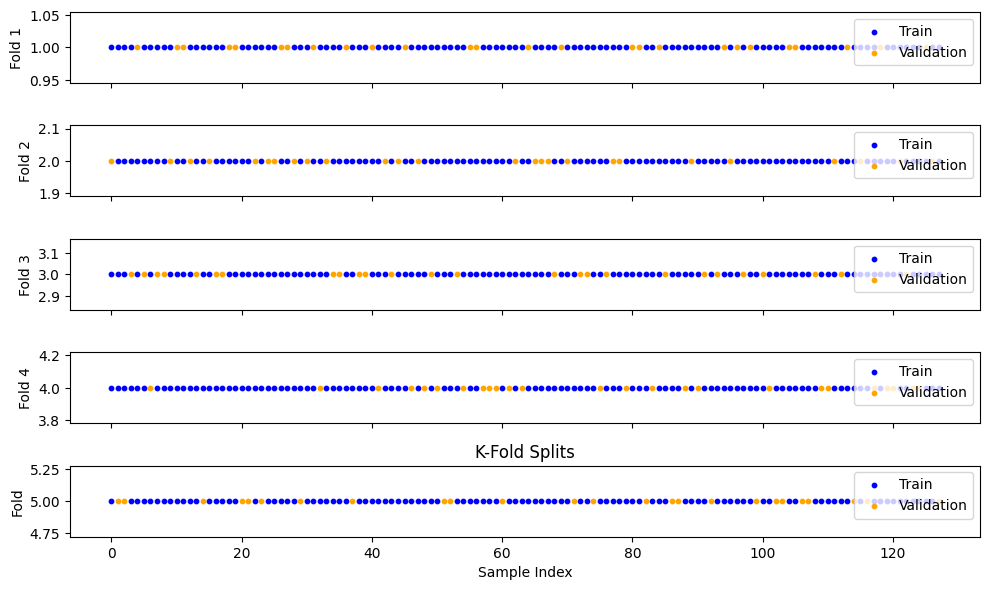

In [45]:
import matplotlib.pyplot as plt

# Visualize KFold splits of the original data
n_samples = len(y)
folds = list(kf.split(X))

fig, ax = plt.subplots(len(folds), 1, figsize=(10, 6), sharex=True)

for i, (train_idx, val_idx) in enumerate(folds):
    ax[i].scatter(train_idx, [i+1] * len(train_idx), label="Train", c="blue", s=10)
    ax[i].scatter(val_idx, [i+1] * len(val_idx), label="Validation", c="orange", s=10)
    ax[i].set_ylabel(f"Fold {i+1}")
    ax[i].legend(loc='upper right')

plt.xlabel("Sample Index")
plt.ylabel("Fold")
plt.title("K-Fold Splits")
plt.tight_layout()
plt.show()

### Performance Across Folds

The plot below show how each fold performs in terms of MSE.

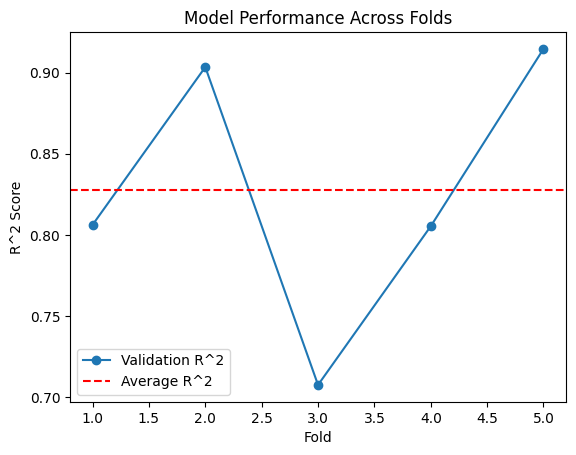

In [35]:
# Plot validation scores
plt.plot(range(1, len(scores) + 1), scores, marker='o', label="Validation R^2")
plt.axhline(y=avg_score, color='r', linestyle='--', label="Average R^2")
plt.title("Model Performance Across Folds")
plt.xlabel("Fold")
plt.ylabel("R^2 Score")
plt.legend()
plt.show()

### Visualize Predictions

This plot shows the predicted values for the first fold. Greater distance from the dashed line indicates worse predictions.

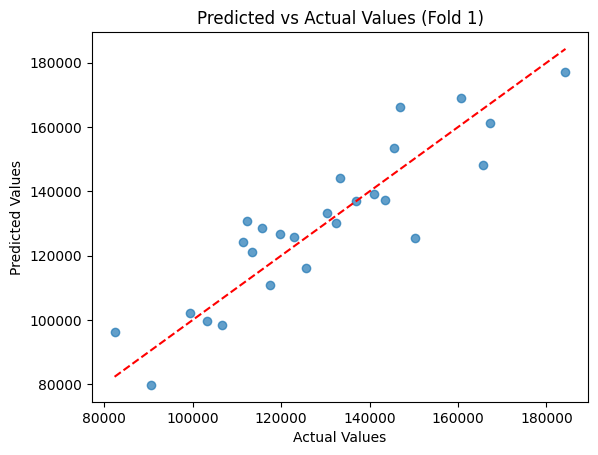

In [36]:
# Example: Visualize predictions for the first fold
X_train, X_val = X[folds[0][0]], X[folds[0][1]]
y_train, y_val = y[folds[0][0]], y[folds[0][1]]

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_val)

plt.scatter(y_val, y_pred, alpha=0.7)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')  # Perfect fit line
plt.title("Predicted vs Actual Values (Fold 1)")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.show()

### Compare Fold Predictions

Visualize the difference between the best and worst fold performances. Distance from the dashed line indicates performance. Greater vertical distance indicates worse performance of the individual prediction. The absolute distance from the line is indicated by the RMS error.

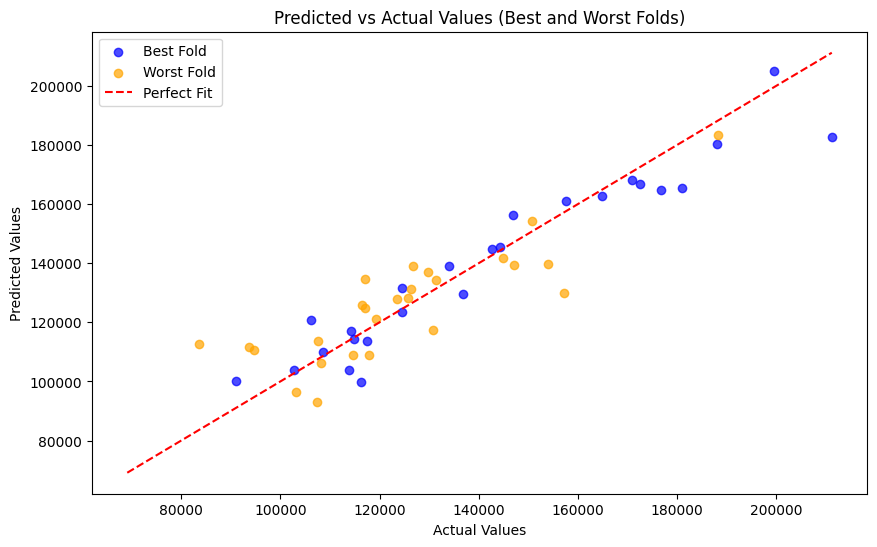

In [46]:
# Identify the best and worst folds based on scores
best_fold_idx = np.argmax(scores)
worst_fold_idx = np.argmin(scores)

# Get data for the best and worst folds
best_train_idx, best_val_idx = folds[best_fold_idx]
worst_train_idx, worst_val_idx = folds[worst_fold_idx]

# Best fold predictions
X_train_best, X_val_best = X[best_train_idx], X[best_val_idx]
y_train_best, y_val_best = y[best_train_idx], y[best_val_idx]
model.fit(X_train_best, y_train_best)
y_pred_best = model.predict(X_val_best)

# Worst fold predictions
X_train_worst, X_val_worst = X[worst_train_idx], X[worst_val_idx]
y_train_worst, y_val_worst = y[worst_train_idx], y[worst_val_idx]
model.fit(X_train_worst, y_train_worst)
y_pred_worst = model.predict(X_val_worst)

# Plot best and worst fold predictions
plt.figure(figsize=(10, 6))

# Best fold
plt.scatter(y_val_best, y_pred_best, alpha=0.7, label="Best Fold", c="blue")

# Worst fold
plt.scatter(y_val_worst, y_pred_worst, alpha=0.7, label="Worst Fold", c="orange")

# Perfect fit line
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', label="Perfect Fit")

plt.title("Predicted vs Actual Values (Best and Worst Folds)")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.legend()
plt.show()

### Visualize Residuals

The distance from the red line indicates actual value from the predicted value. Greater distance from the red line indicates worse predictions. Values above the line indicate over valuation, while under the line shows under valuation.

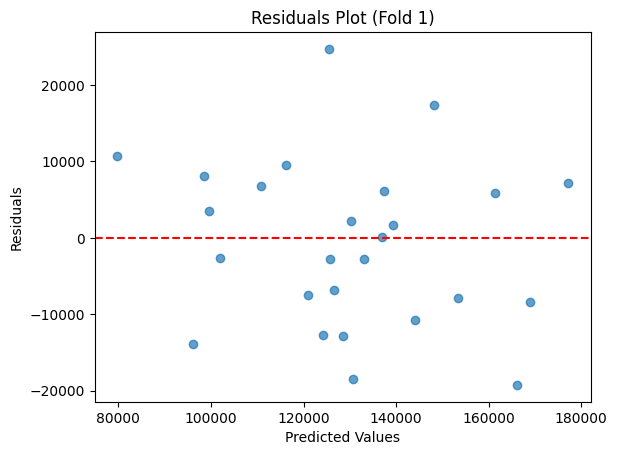

In [38]:
# Example residuals plot for one fold
residuals = y_val - y_pred
plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(0, color='r', linestyle='--')
plt.title("Residuals Plot (Fold 1)")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.show()

### Residuals for Best and Worst Fold

This compares the best and worst folds in terms of residuals. This is another way of visualizing the plot above.

This shows that the best fold has a smaller absolute residual (distance from the red line). The plot on the left has more values closer to the dashed line. The plot on the right tends to undervalue property significantly more than the plot on the left.

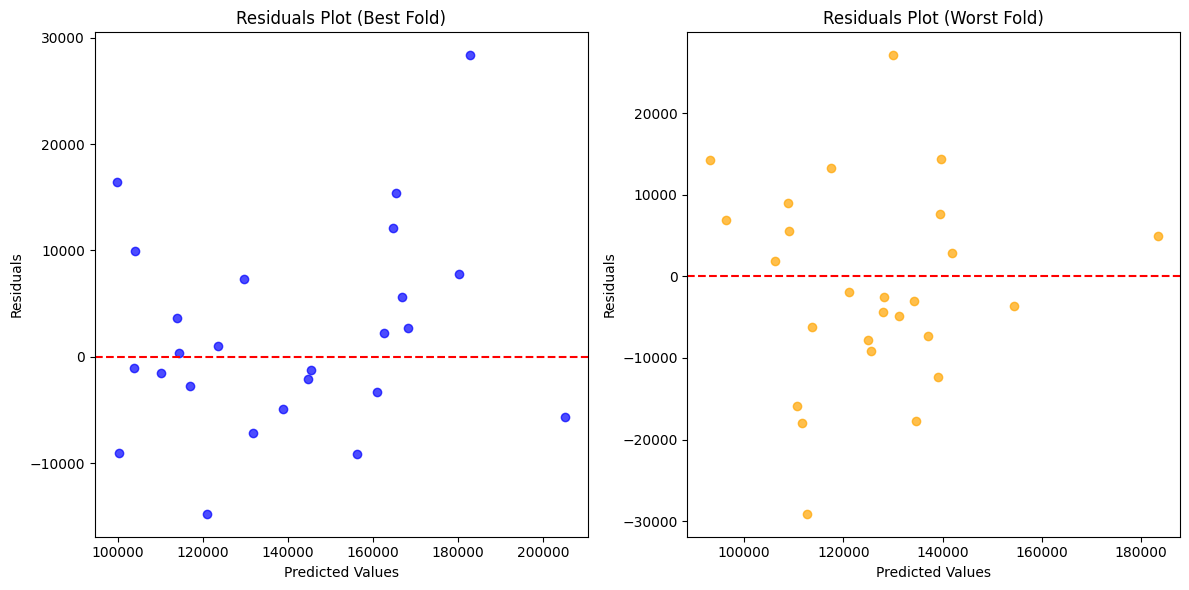

In [47]:
# Best and worst fold indices
best_fold_idx = scores.index(max(scores))
worst_fold_idx = scores.index(min(scores))

# Prepare data for best fold
X_train_best, X_val_best = X[folds[best_fold_idx][0]], X[folds[best_fold_idx][1]]
y_train_best, y_val_best = y[folds[best_fold_idx][0]], y[folds[best_fold_idx][1]]

# Train and predict for best fold
model_best = LinearRegression()
model_best.fit(X_train_best, y_train_best)
y_pred_best = model_best.predict(X_val_best)
residuals_best = y_val_best - y_pred_best

# Prepare data for worst fold
X_train_worst, X_val_worst = X[folds[worst_fold_idx][0]], X[folds[worst_fold_idx][1]]
y_train_worst, y_val_worst = y[folds[worst_fold_idx][0]], y[folds[worst_fold_idx][1]]

# Train and predict for worst fold
model_worst = LinearRegression()
model_worst.fit(X_train_worst, y_train_worst)
y_pred_worst = model_worst.predict(X_val_worst)
residuals_worst = y_val_worst - y_pred_worst

# Plot residuals for both folds
plt.figure(figsize=(12, 6))

# Best fold residuals
plt.subplot(1, 2, 1)
plt.scatter(y_pred_best, residuals_best, alpha=0.7, color='blue')
plt.axhline(y=0, color='red', linestyle='--')
plt.title("Residuals Plot (Best Fold)")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

# Worst fold residuals
plt.subplot(1, 2, 2)
plt.scatter(y_pred_worst, residuals_worst, alpha=0.7, color='orange')
plt.axhline(y=0, color='red', linestyle='--')
plt.title("Residuals Plot (Worst Fold)")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.tight_layout()
plt.show()

### Distribution of Predicted vs Actual Values

This plot agregates all of the fold predictions into one histogram. The overlapping values shows where the model succeeds; where there is no overlap, the model has worse predictions. 

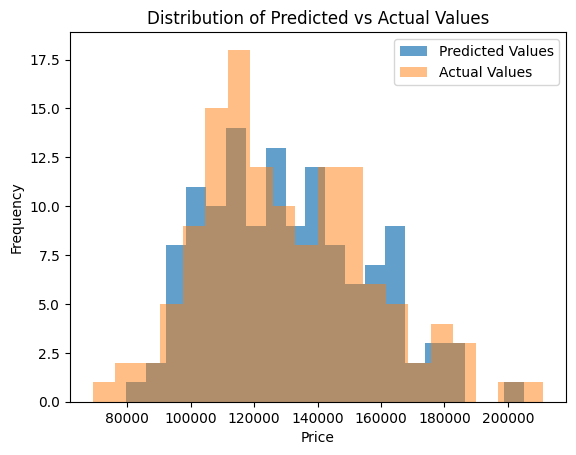

In [39]:
all_preds = []

for train_idx, val_idx in kf.split(X):
    model.fit(X[train_idx], y[train_idx])
    all_preds.extend(model.predict(X[val_idx]))

plt.hist(all_preds, bins=20, alpha=0.7, label="Predicted Values")
plt.hist(y, bins=20, alpha=0.5, label="Actual Values")
plt.title("Distribution of Predicted vs Actual Values")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.legend()
plt.show()

### Comparison of Best and Worst Folds

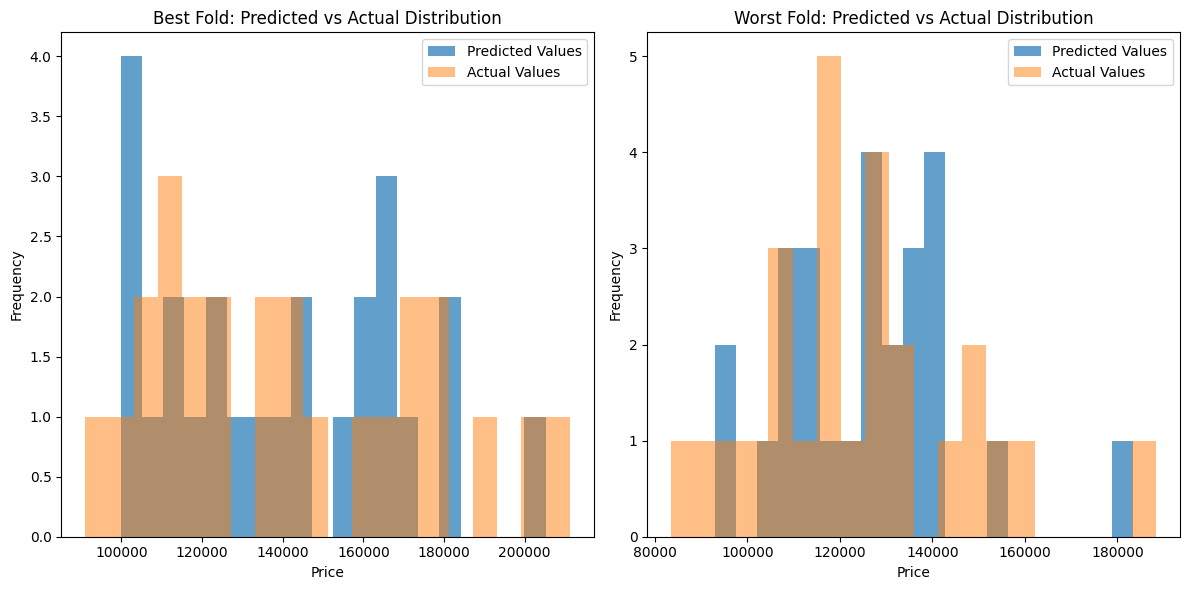

In [48]:
import numpy as np
import matplotlib.pyplot as plt

# Identify the best and worst folds based on scores
best_fold_idx = np.argmax(scores)
worst_fold_idx = np.argmin(scores)

# Prepare predictions for the best fold
best_train_idx, best_val_idx = folds[best_fold_idx]
model.fit(X[best_train_idx], y[best_train_idx])
best_preds = model.predict(X[best_val_idx])

# Prepare predictions for the worst fold
worst_train_idx, worst_val_idx = folds[worst_fold_idx]
model.fit(X[worst_train_idx], y[worst_train_idx])
worst_preds = model.predict(X[worst_val_idx])

# Plot for the best fold
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(best_preds, bins=20, alpha=0.7, label="Predicted Values")
plt.hist(y[best_val_idx], bins=20, alpha=0.5, label="Actual Values")
plt.title("Best Fold: Predicted vs Actual Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.legend()

# Plot for the worst fold
plt.subplot(1, 2, 2)
plt.hist(worst_preds, bins=20, alpha=0.7, label="Predicted Values")
plt.hist(y[worst_val_idx], bins=20, alpha=0.5, label="Actual Values")
plt.title("Worst Fold: Predicted vs Actual Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.legend()

plt.tight_layout()
plt.show()